# EN3160 Assignment 01
## Intensity Transformations and Neighborhood Filtering

**Name:** Rahman MFA        
**Index Number:** 230507R           
**GitHub:** https://github.com/Abdul-Rahman-bme/EN3160-Image-processing-and-Machine-Vision

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
IMAGE_DIR = Path("images")
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

# Question 1 — Piecewise Intensity Transformation

A piecewise-linear intensity transformation maps each input grayscale intensity
to an output intensity using a set of user-defined breakpoints. Linear
interpolation is used between successive breakpoints. The breakpoint locations
control which intensity ranges are stretched or compressed and therefore
control the contrast of the resulting image.

In [4]:
img_q1 = cv.imread(str(IMAGE_DIR / "q1_portrait.png"), cv.IMREAD_GRAYSCALE)

if img_q1 is None:
    raise FileNotFoundError("Q1 image could not be loaded.")

print("Image shape:", img_q1.shape)
print("Data type:", img_q1.dtype)
print("Intensity range:", img_q1.min(), "to", img_q1.max())

Image shape: (451, 401)
Data type: uint8
Intensity range: 0 to 253


In [5]:
def intensity_transform(im, breakpoints):
    
    bp = np.asarray(breakpoints, dtype=np.float32)

    # Basic checks
    if bp.ndim != 2 or bp.shape[1] != 2:
        raise ValueError("breakpoints must have shape (N, 2)")

    x = bp[:, 0]
    y = bp[:, 1]

    if not np.all(np.diff(x) > 0):
        raise ValueError("Input breakpoint values must be strictly increasing.")

    output = np.zeros_like(im, dtype=np.float32)
    im_float = im.astype(np.float32)

    # Apply each linear segment
    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]

        if i == len(bp) - 2:
            mask = (im_float >= x0) & (im_float <= x1)
        else:
            mask = (im_float >= x0) & (im_float < x1)

        slope = (y1 - y0) / (x1 - x0)

        output[mask] = y0 + slope * (im_float[mask] - x0)

    return np.clip(np.round(output), 0, 255).astype(np.uint8)

In [6]:
breakpoints_example = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

img_q1_example = intensity_transform(img_q1, breakpoints_example)

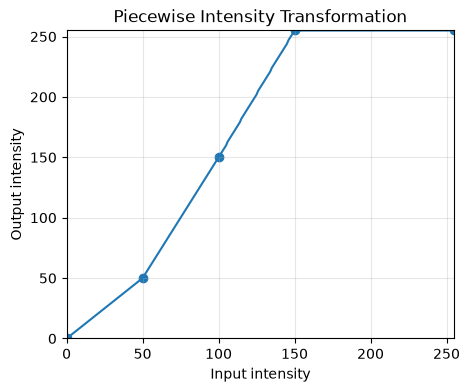

In [7]:
input_levels = np.arange(256, dtype=np.uint8)

mapped_levels = intensity_transform(
    input_levels,
    breakpoints_example
)

plt.figure(figsize=(5, 4))

plt.plot(input_levels, mapped_levels)
plt.scatter(
    breakpoints_example[:, 0],
    breakpoints_example[:, 1]
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Intensity Transformation")
plt.grid(alpha=0.3)

plt.show()

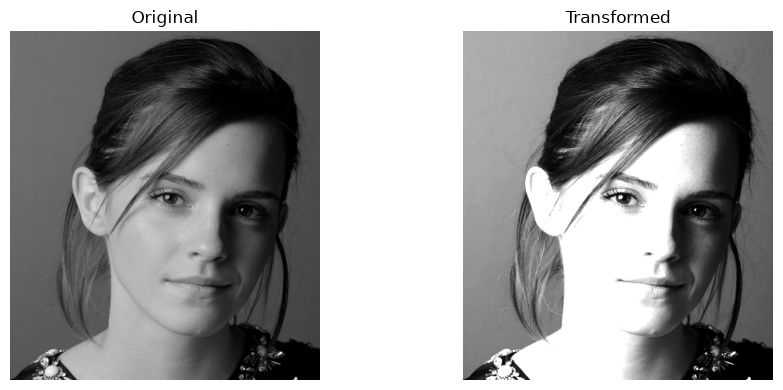

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_q1_example, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
breakpoints_1 = np.array([
    [0,   0],
    [50,  35],
    [100, 110],
    [160, 210],
    [220, 245],
    [255, 255]
], dtype=np.float32)

breakpoints_2 = np.array([
    [0,   0],
    [40,  25],
    [90,  80],
    [140, 175],
    [190, 230],
    [255, 255]
], dtype=np.float32)

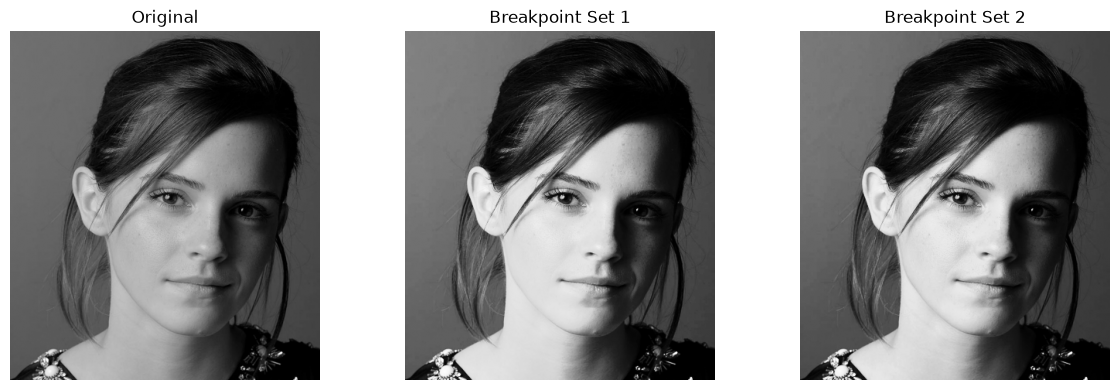

In [10]:
img_bp1 = intensity_transform(img_q1, breakpoints_1)
img_bp2 = intensity_transform(img_q1, breakpoints_2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_bp1, cmap="gray", vmin=0, vmax=255)
plt.title("Breakpoint Set 1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_bp2, cmap="gray", vmin=0, vmax=255)
plt.title("Breakpoint Set 2")
plt.axis("off")

plt.tight_layout()
plt.show()

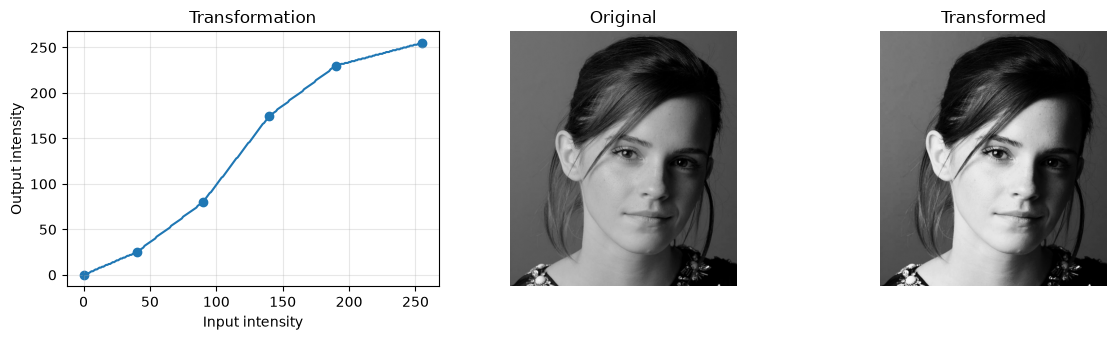

In [11]:
best_breakpoints = breakpoints_2   # replace after experimentation
best_img = intensity_transform(img_q1, best_breakpoints)

levels = np.arange(256, dtype=np.uint8)
mapped = intensity_transform(levels, best_breakpoints)

plt.figure(figsize=(12, 3.5))

plt.subplot(1, 3, 1)
plt.plot(levels, mapped)
plt.scatter(best_breakpoints[:, 0], best_breakpoints[:, 1])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(best_img, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()

# Question 2 — White and Gray Matter Enhancement

White matter and gray matter occupy different intensity ranges in the proton
density image. Piecewise-linear intensity transformations were therefore used
to selectively expand the ranges associated with each tissue. Expanding a
target range increases its contrast while compressing less relevant intensity
regions.

In [12]:
img_q2 = cv.imread(str(IMAGE_DIR / "q2_brain.png"), cv.IMREAD_GRAYSCALE)

if img_q2 is None:
    raise FileNotFoundError("Q2 brain image could not be loaded.")

print("Shape:", img_q2.shape)
print("Data type:", img_q2.dtype)
print("Intensity range:", img_q2.min(), "to", img_q2.max())

Shape: (481, 401)
Data type: uint8
Intensity range: 0 to 255


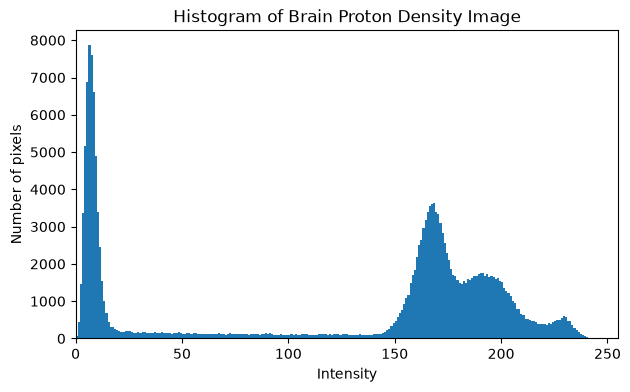

In [13]:
plt.figure(figsize=(7, 4))

plt.hist(
    img_q2.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Proton Density Image")
plt.xlim(0, 255)

plt.show()

In [14]:
percentiles = np.percentile(
    img_q2,
    [1, 5, 10, 25, 50, 75, 90, 95, 99]
)

for p, value in zip(
    [1, 5, 10, 25, 50, 75, 90, 95, 99],
    percentiles
):
    print(f"{p:>2}% : {value:.1f}")

 1% : 2.0
 5% : 4.0
10% : 6.0
25% : 11.0
50% : 165.0
75% : 185.0
90% : 202.0
95% : 215.0
99% : 232.0


In [15]:
white_bp = np.array([
    [0,   0],
    [90,  40],
    [110, 90],
    [140, 220],
    [180, 245],
    [255, 255]
], dtype=np.float32)

gray_bp = np.array([
    [0,   0],
    [80,  30],
    [120, 70],
    [155, 210],
    [200, 245],
    [255, 255]
], dtype=np.float32)

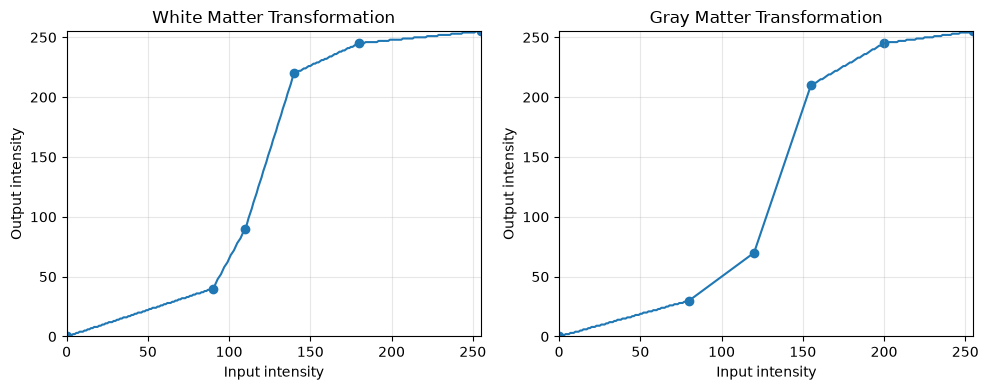

In [16]:
white_enhanced = intensity_transform(img_q2, white_bp)
gray_enhanced = intensity_transform(img_q2, gray_bp)
levels = np.arange(256, dtype=np.uint8)

white_curve = intensity_transform(levels, white_bp)
gray_curve = intensity_transform(levels, gray_bp)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(levels, white_curve)
plt.scatter(white_bp[:, 0], white_bp[:, 1])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(levels, gray_curve)
plt.scatter(gray_bp[:, 0], gray_bp[:, 1])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

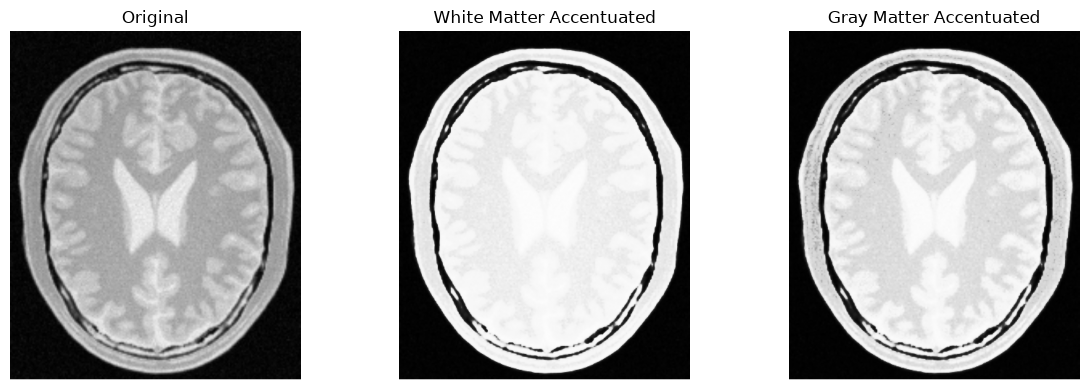

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_q2, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(white_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

### Discussion

The white-matter transformation was chosen to strongly stretch the intensity
range containing white-matter pixels, making their boundaries more distinct
from surrounding tissue. A different breakpoint set was required for gray
matter because its intensities occupy a different part of the histogram.
Ranges outside the regions of interest were compressed to allocate more of
the available output intensity range to the targeted tissue.

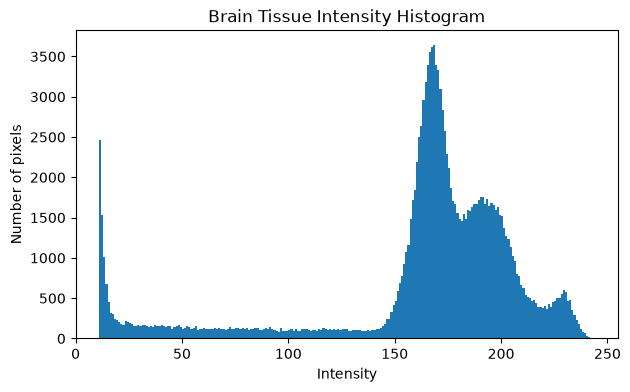

Min: 11
Max: 255
Mean: 161.85201240523776
Median: 171.0


In [18]:
brain_pixels = img_q2[img_q2 > 10]

plt.figure(figsize=(7, 4))
plt.hist(brain_pixels.ravel(), bins=256, range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Brain Tissue Intensity Histogram")
plt.xlim(0, 255)

plt.show()

print("Min:", brain_pixels.min())
print("Max:", brain_pixels.max())
print("Mean:", brain_pixels.mean())
print("Median:", np.median(brain_pixels))

In [19]:
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"{p}%: {np.percentile(brain_pixels, p):.1f}")

5%: 20.0
10%: 69.0
25%: 160.0
50%: 171.0
75%: 192.0
90%: 207.0
95%: 221.0


In [20]:
white_bp = np.array([
    [0,   0],
    [140, 35],
    [165, 70],
    [195, 220],
    [220, 245],
    [255, 255]
], dtype=np.float32)

gray_bp = np.array([
    [0,   0],
    [130, 30],
    [150, 70],
    [175, 210],
    [200, 235],
    [255, 255]
], dtype=np.float32)

white_enhanced = intensity_transform(img_q2, white_bp)
gray_enhanced = intensity_transform(img_q2, gray_bp)

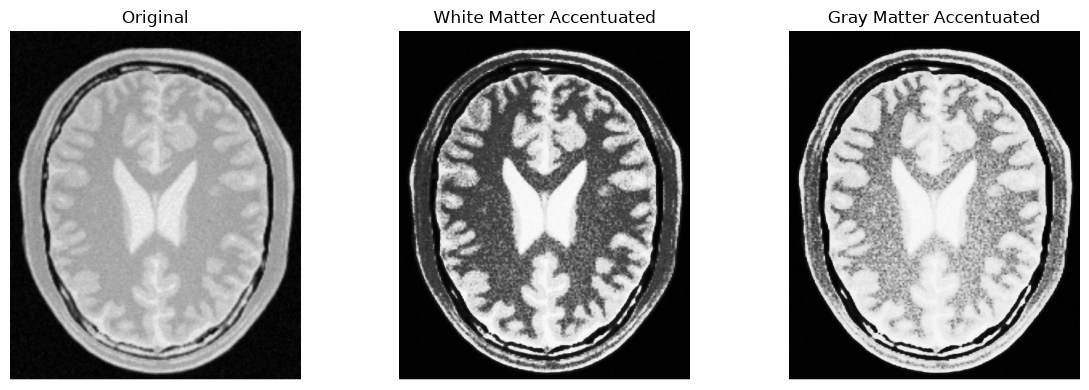

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_q2, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(white_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

### Method

White matter and gray matter occupy different grayscale intensity ranges in the
proton-density image. Separate piecewise-linear intensity transformations were
therefore designed to expand the intensity range associated with each target
tissue. A slope greater than one within the selected range increases contrast,
while the remaining intensity ranges are compressed to preserve the available
output range.

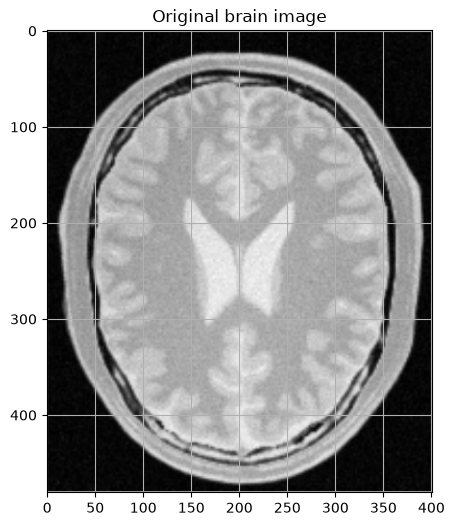

In [22]:
plt.figure(figsize=(6, 6))
plt.imshow(img_q2, cmap="gray", vmin=0, vmax=255)
plt.title("Original brain image")
plt.axis("on")
plt.grid()
plt.show()

In [23]:
points = [
    (120, 120),
    (150, 150),
    (100, 160)
]

for x, y in points:
    print(f"({x}, {y}) -> intensity = {img_q2[y, x]}")

(120, 120) -> intensity = 189
(150, 150) -> intensity = 163
(100, 160) -> intensity = 166


In [24]:
def roi_mean(im, x, y, r=3):
    roi = im[y-r:y+r+1, x-r:x+r+1]
    return roi.mean()

print(roi_mean(img_q2, 120, 120))

185.87755102040816


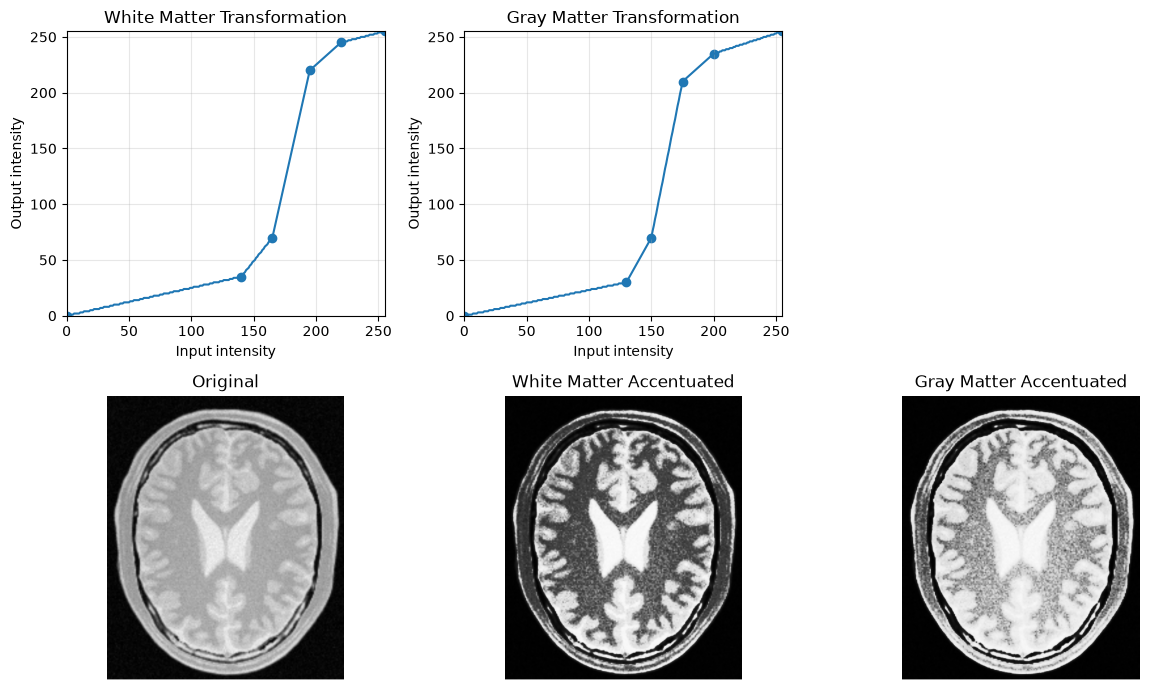

In [25]:
levels = np.arange(256, dtype=np.uint8)

white_curve = intensity_transform(levels, white_bp)
gray_curve = intensity_transform(levels, gray_bp)

plt.figure(figsize=(12, 7))

plt.subplot(2, 3, 1)
plt.plot(levels, white_curve)
plt.scatter(white_bp[:, 0], white_bp[:, 1])
plt.title("White Matter Transformation")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(levels, gray_curve)
plt.scatter(gray_bp[:, 0], gray_bp[:, 1])
plt.title("Gray Matter Transformation")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
plt.imshow(img_q2, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(white_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gray_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

### Discussion

Separate piecewise-linear mappings were used to expand different tissue intensity ranges. 
The white-matter mapping strongly stretches its selected mid-to-high intensity range, increasing contrast between the darker internal tissue and brighter structures. 
The gray-matter mapping shifts the strongest contrast expansion toward a slightly different intensity range, producing a different enhancement of the cortical tissue. 
The transformations therefore emphasize different tissue intensity bands rather than simply increasing the overall brightness of the image.

In [26]:
img_q3 = cv.imread(str(IMAGE_DIR / "q3_gamma.png"))

if img_q3 is None:
    raise FileNotFoundError("Q3 image could not be loaded.")

img_q3_rgb = cv.cvtColor(img_q3, cv.COLOR_BGR2RGB)

In [27]:
lab = cv.cvtColor(img_q3, cv.COLOR_BGR2LAB)

L, a, b = cv.split(lab)

#### Gamma correction function

In [28]:
def gamma_correct(channel, gamma):
    channel_norm = channel.astype(np.float32) / 255.0

    corrected = np.power(channel_norm, gamma)

    corrected = corrected * 255.0

    return np.clip(corrected, 0, 255).astype(np.uint8)

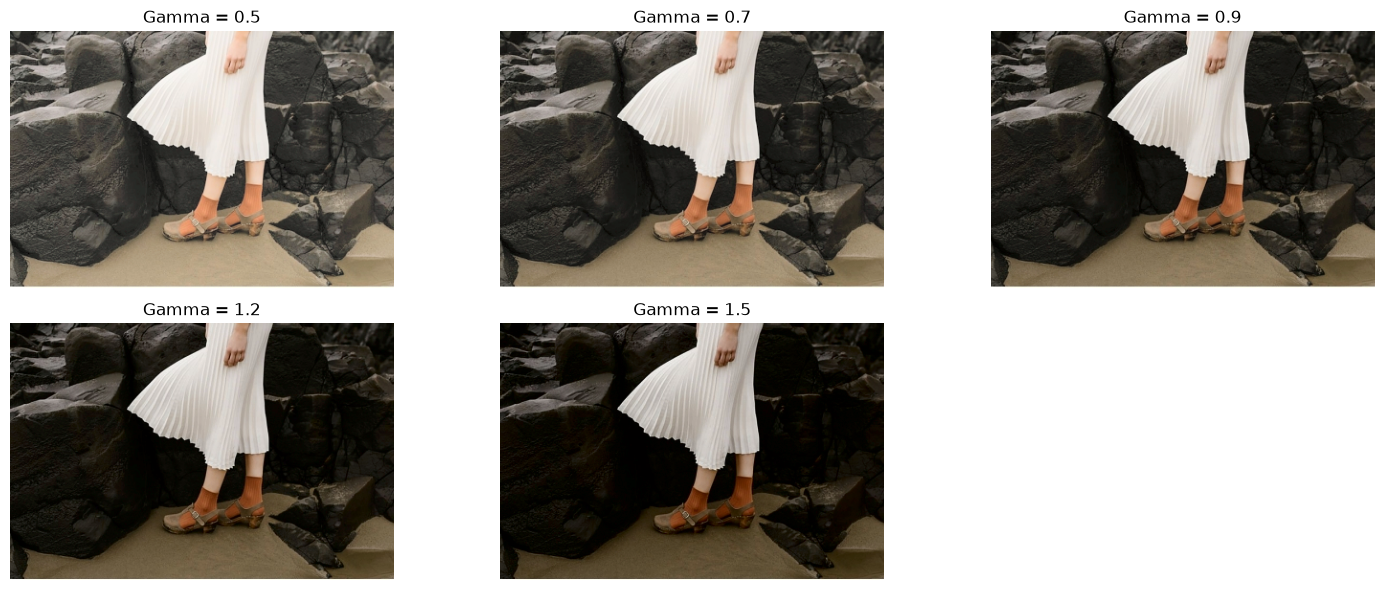

In [29]:
gamma_values = [0.5, 0.7, 0.9, 1.2, 1.5]

plt.figure(figsize=(15, 6))

for i, gamma in enumerate(gamma_values):
    L_corr = gamma_correct(L, gamma)

    lab_corr = cv.merge([L_corr, a, b])
    bgr_corr = cv.cvtColor(lab_corr, cv.COLOR_LAB2BGR)
    rgb_corr = cv.cvtColor(bgr_corr, cv.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(rgb_corr)
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
gamma = 0.7
L_corrected = gamma_correct(L, gamma)

lab_corrected = cv.merge([L_corrected, a, b])

img_corrected_bgr = cv.cvtColor(
    lab_corrected,
    cv.COLOR_LAB2BGR
)

img_corrected_rgb = cv.cvtColor(
    img_corrected_bgr,
    cv.COLOR_BGR2RGB
)

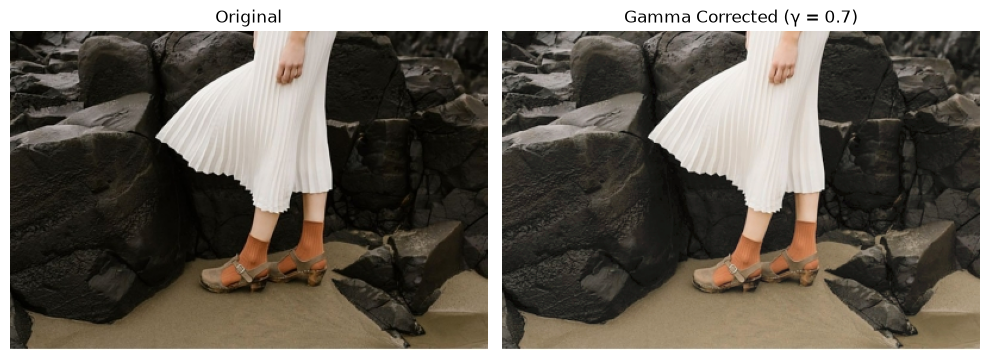

In [37]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_q3_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

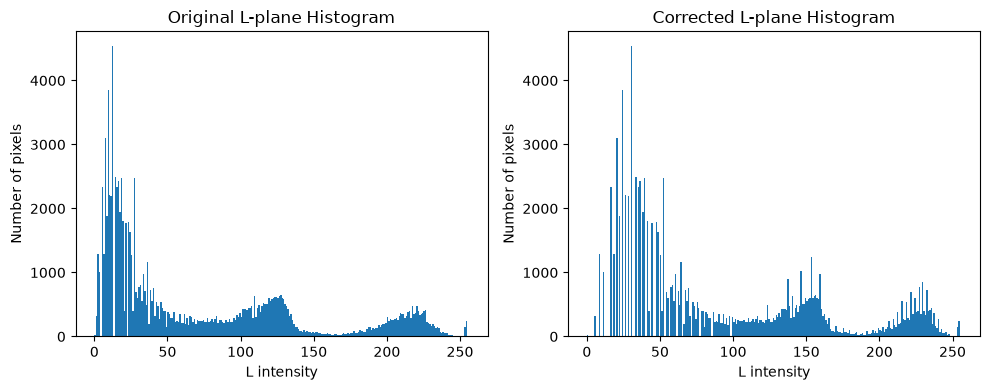

In [38]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 256))
plt.title("Original L-plane Histogram")
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=(0, 256))
plt.title("Corrected L-plane Histogram")
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

# Question 3 — Gamma Correction in L*a*b*

The image was converted from BGR to the L*a*b* color space so that gamma correction could be applied only to the lightness component. The L plane was normalized to the range [0,1], transformed using

\[
s=r^\gamma,
\]

and then rescaled to the 8-bit intensity range. The corrected L plane was recombined with the original a and b planes before converting the image back to RGB.

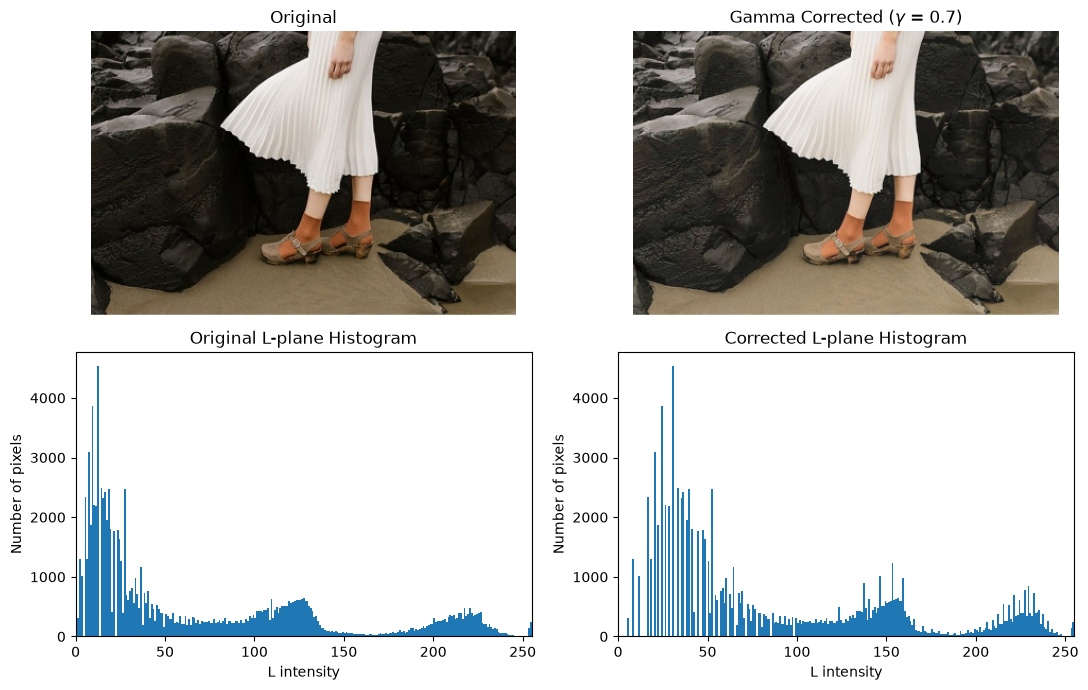

In [39]:
plt.figure(figsize=(11, 7))

# Original
plt.subplot(2, 2, 1)
plt.imshow(img_q3_rgb)
plt.title("Original")
plt.axis("off")

# Gamma corrected
plt.subplot(2, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(f"Gamma Corrected ($\\gamma$ = {gamma})")
plt.axis("off")

# Original L histogram
plt.subplot(2, 2, 3)
plt.hist(L.ravel(), bins=256, range=(0, 256))
plt.title("Original L-plane Histogram")
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")
plt.xlim(0, 255)

# Corrected L histogram
plt.subplot(2, 2, 4)
plt.hist(L_corrected.ravel(), bins=256, range=(0, 256))
plt.title("Corrected L-plane Histogram")
plt.xlabel("L intensity")
plt.ylabel("Number of pixels")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

### Discussion

A gamma value of $\gamma=0.7$ was selected after comparing several values. Since
$\gamma<1$, the lower and mid-level lightness values were increased, revealing
more detail in the dark rock regions while preserving the bright regions reasonably
well. The correction was applied only to the L plane, while the original a and b
channels were retained. The corrected L-plane histogram shifts toward higher
intensities, which agrees with the expected behavior of gamma correction for
$\gamma<1$.

## Question 4 - Vibrance

In [40]:
img_q4 = cv.imread(str(IMAGE_DIR / "q4_vibrance.png"))

if img_q4 is None:
    raise FileNotFoundError("Q4 image could not be loaded.")

img_q4_rgb = cv.cvtColor(img_q4, cv.COLOR_BGR2RGB)

In [41]:
hsv = cv.cvtColor(img_q4, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

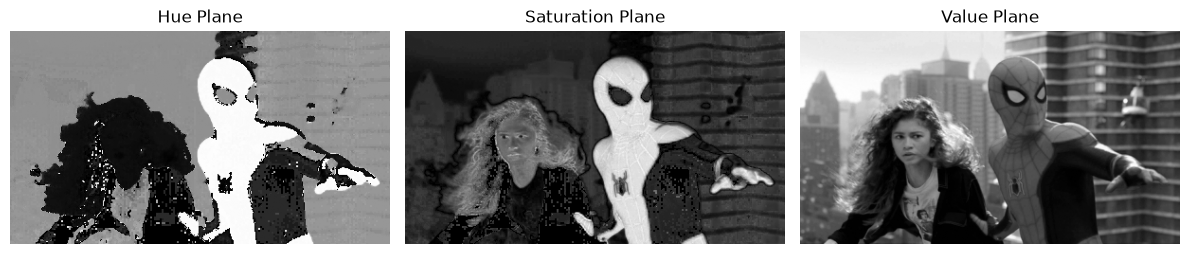

In [42]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Implementing the vibrance transformation

In [43]:
def vibrance_transform(S, a, sigma=70):
    S_float = S.astype(np.float32)

    boost = a * 128.0 * np.exp(
        -((S_float - 128.0) ** 2) / (2.0 * sigma ** 2)
    )

    S_new = S_float + boost

    return np.clip(S_new, 0, 255).astype(np.uint8)

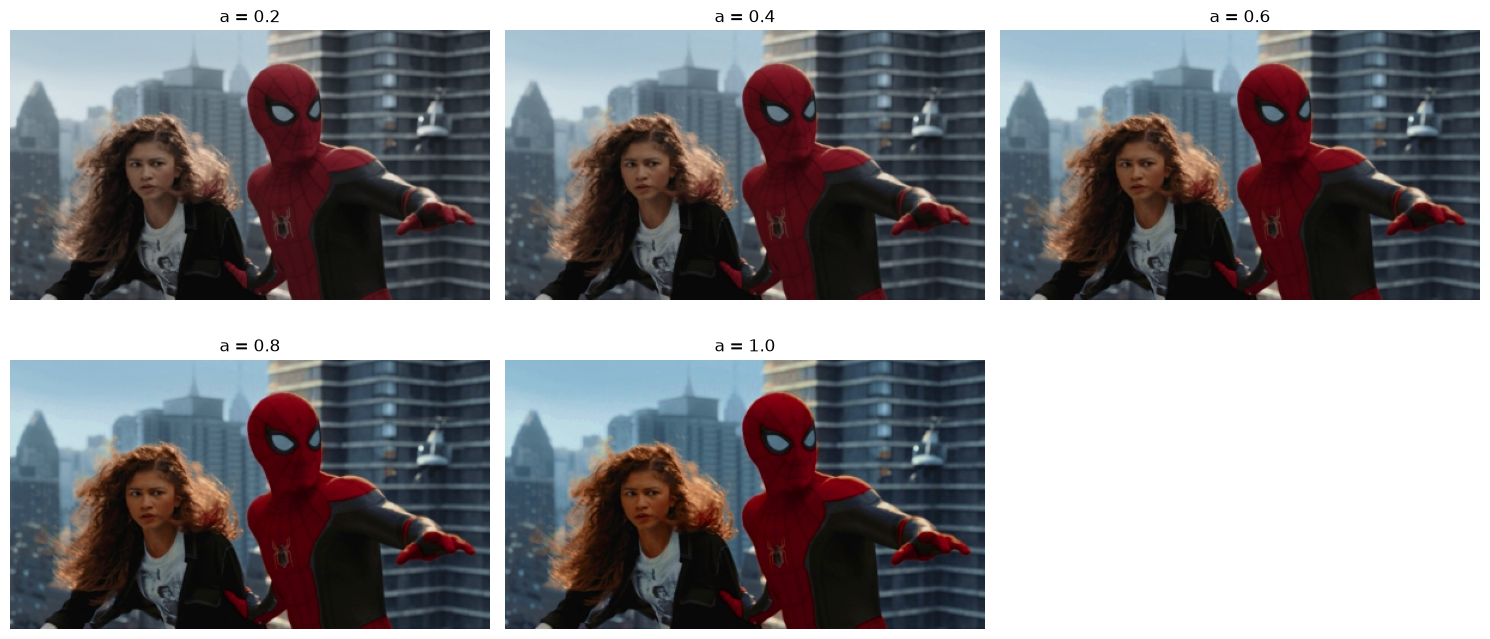

In [44]:
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(15, 7))

for i, a_val in enumerate(a_values):
    S_corr = vibrance_transform(S, a_val)

    hsv_corr = cv.merge([H, S_corr, V])
    bgr_corr = cv.cvtColor(hsv_corr, cv.COLOR_HSV2BGR)
    rgb_corr = cv.cvtColor(bgr_corr, cv.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(rgb_corr)
    plt.title(f"a = {a_val}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
a = 0.6
S_enhanced = vibrance_transform(S, a)

hsv_enhanced = cv.merge([H, S_enhanced, V])

img_q4_enhanced_bgr = cv.cvtColor(
    hsv_enhanced,
    cv.COLOR_HSV2BGR
)

img_q4_enhanced_rgb = cv.cvtColor(
    img_q4_enhanced_bgr,
    cv.COLOR_BGR2RGB
)

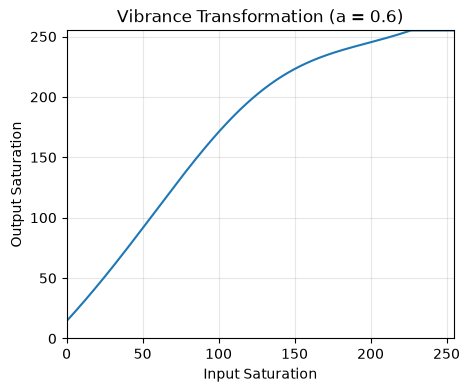

In [47]:
x = np.arange(256, dtype=np.float32)

y = x + a * 128.0 * np.exp(
    -((x - 128.0) ** 2) / (2.0 * 70 ** 2)
)

y = np.clip(y, 0, 255)

plt.figure(figsize=(5, 4))
plt.plot(x, y)
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Vibrance Transformation (a = {a})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)
plt.show()

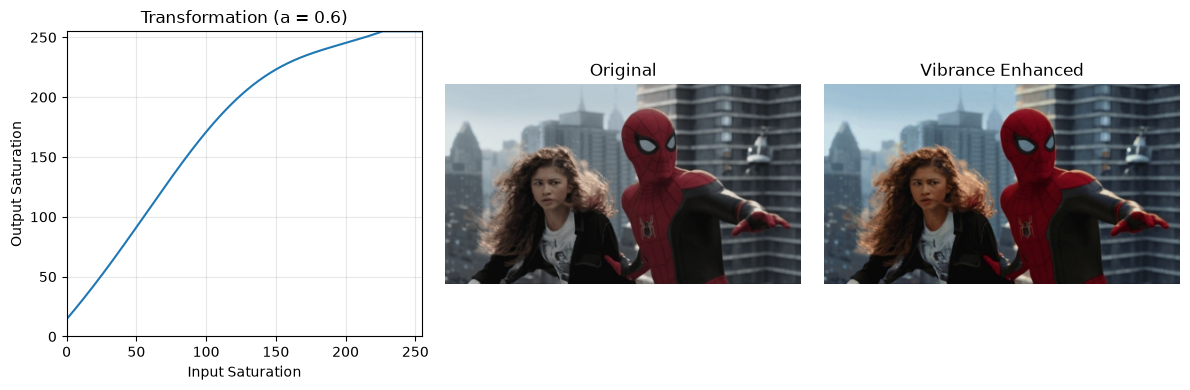

In [48]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, y)
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Transformation (a = {a})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(img_q4_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_q4_enhanced_rgb)
plt.title("Vibrance Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

# Question 4 — Vibrance Enhancement

The image was converted to HSV so that saturation could be modified independently
from hue and brightness. The supplied nonlinear transformation was applied only
to the saturation plane. The Gaussian term is centered at a saturation value of
128, causing medium-saturation pixels to receive the strongest increase, while
pixels far from this value receive a smaller adjustment.

### Discussion

Several values of \(a\) were tested to control the strength of the saturation
enhancement. A value of \(a=0.6\) was selected because it produced a noticeable
increase in color vibrance while maintaining a reasonably natural appearance.
The Gaussian-shaped transformation gives its strongest saturation increase to
intermediate saturation values around 128, while values farther from this point
receive a smaller boost. Larger values of \(a\) produced stronger saturation
and increased the likelihood of clipping at the maximum value of 255.